# Heart Disease Prediction Using Machine Learning

**College:** C. K. Pithawala College of Engineering and Technology, Surat

**Department:** Computer Engineering Department

**Course:** Machine Learning (3170724) — Year IV, 7th Semester

**Assessment:** Course-Integrated Practical & Analytical Task (CIPAT)

**Faculty:** Mithila Parekh

**Project Domain:** Machine Learning — Healthcare
**Project Title:** Heart Disease Prediction Using Machine Learning

**Group Members:**

| Sr. No. | Name | Enrollment No. |
|---|---|---|
| 1 | Smit Panseriya | 220090107103 |
| 2 | Harshal Vora | 220090107207 |
| 3 | Raj Padshala | 230090107106 |
| 4 | Pruthil Vaghasiya | 230090107228 |

## 1. Introduction

**Problem Statement:** Heart disease is conventionally diagnosed with invasive and expensive procedures such as angiography. This project uses routinely collected clinical measurements (age, blood pressure, cholesterol, ECG results, etc.) to build machine learning models that predict whether a patient has heart disease, enabling faster and cheaper risk screening.

**Objectives:**
1. Select and preprocess a real clinical dataset collected from four hospitals.
2. Visualize the data and study the relationships between clinical features and heart disease.
3. Implement and compare five supervised classification algorithms.
4. Implement and compare two unsupervised clustering algorithms.
5. Select the best model, check it against the requirement of more than 80% accuracy, and discuss real-world applications and limitations.

## 2. Dataset Description

**Dataset Name:** UCI Heart Disease Dataset (combined: Cleveland + Hungarian +
Switzerland + VA Long Beach)

**Source / Link:** https://archive.ics.uci.edu/dataset/45/heart+disease

**Description:**
The dataset contains clinical records from four hospitals. While the raw data has 76
attributes, all published research uses a standard subset of **14 attributes**. We
combine all four processed files into a single dataset of **920 patient records**,
adding a `source` column to track the originating hospital — this makes the dataset
more realistic (heterogeneous, with varying amounts of missing data per source) than
using a single clean hospital's data.

| # | Attribute | Description |
|---|---|---|
| 1 | age | Age in years |
| 2 | sex | Sex (1 = male, 0 = female) |
| 3 | cp | Chest pain type (1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic) |
| 4 | trestbps | Resting blood pressure (mm Hg) |
| 5 | chol | Serum cholesterol (mg/dl) |
| 6 | fbs | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) |
| 7 | restecg | Resting ECG results (0, 1, 2) |
| 8 | thalach | Maximum heart rate achieved |
| 9 | exang | Exercise-induced angina (1 = yes, 0 = no) |
| 10 | oldpeak | ST depression induced by exercise relative to rest |
| 11 | slope | Slope of the peak exercise ST segment |
| 12 | ca | Number of major vessels (0–3) colored by fluoroscopy (dropped, see 5.3) |
| 13 | thal | Thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect) (dropped, see 5.3) |
| 14 | num | Diagnosis of heart disease (0 = absence, 1–4 = increasing severity) — **target** |
| 15 | source | Hospital of origin (added by us for traceability) |

**Target variable used in this project:** `target` = 1 if `num` > 0 (disease present),
else 0 (disease absent) — a **binary classification** framing, as is standard practice
for this dataset in the literature.

## 3. Import Required Libraries

**Task:** Import the libraries for data handling, visualization, modelling and evaluation.

In [34]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, silhouette_score, adjusted_rand_score)
from scipy.cluster.hierarchy import dendrogram, linkage

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
print("Libraries imported successfully.")

Libraries imported successfully.


## 4. Load the Dataset

**Task:** Read the CSV file, then check its shape, data types and the number of records per hospital.

In [35]:
df = pd.read_csv('dataset/heart_disease_combined.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (920, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,Cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  num       920 non-null    int64  
 14  source    920 non-null    object 
dtypes: float64(13), int64(1), object(1)
memory usage: 107.9+ KB


In [37]:
print("Records per source hospital:")
print(df['source'].value_counts())
print("\nOriginal target ('num') distribution (0=absence, 1-4=increasing severity):")
print(df['num'].value_counts().sort_index())

Records per source hospital:
source
Cleveland        303
Hungarian        294
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

Original target ('num') distribution (0=absence, 1-4=increasing severity):
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


## 5. Data Preprocessing

**Task:** Clean the data so that it is ready for modelling. Steps that do not learn anything from the data (fixing invalid values, dropping columns, removing duplicates) are done first. Steps that learn statistics from the data (imputation, outlier limits, scaling) are done after the train-test split, using the training set only, so no information from the test set leaks into the model.

### 5.1 Invalid Zero Values

**Task:** Cholesterol and resting blood pressure cannot be 0 in a living patient. These zeros are placeholders for missing measurements, so convert them to missing values.

In [38]:
zero_chol = df['chol'] == 0
zero_bp = df['trestbps'] == 0
print("Cholesterol == 0 :", zero_chol.sum(), "rows")
print(df.loc[zero_chol, 'source'].value_counts().to_string())
print("Resting BP == 0  :", zero_bp.sum(), "row(s)")

df.loc[zero_chol, 'chol'] = np.nan
df.loc[zero_bp, 'trestbps'] = np.nan

Cholesterol == 0 : 172 rows
source
Switzerland      123
VA Long Beach     49
Resting BP == 0  : 1 row(s)


### 5.2 Missing Value Analysis

**Task:** Count the missing values in each column.

In [39]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_summary[missing_summary['Missing Count'] > 0]

,Missing Count,Missing %
ca,611,66.4
thal,486,52.8
slope,309,33.6
chol,202,22.0
fbs,90,9.8
oldpeak,62,6.7
trestbps,60,6.5
thalach,55,6.0
exang,55,6.0
restecg,2,0.2


### 5.3 Dropping Heavily-Missing Columns

**Task:** Drop `ca` (about 66% missing) and `thal` (about 53% missing). Filling more than half of a column with the most frequent value would mean the model learns from invented data. The remaining missing values are filled in Section 5.7.

In [40]:
df = df.drop(columns=['ca', 'thal'])
continuous_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['fbs', 'restecg', 'exang', 'slope']
df_clean = df.copy()
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'num', 'source']


### 5.4 Duplicate Records

**Task:** Find and remove duplicate rows.

In [41]:
dup_count = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df_clean.shape)

Number of duplicate rows: 2
Shape after removing duplicates: (918, 13)


### 5.5 Outlier Detection

**Task:** Plot box plots of the continuous columns and count the outliers with the IQR rule.

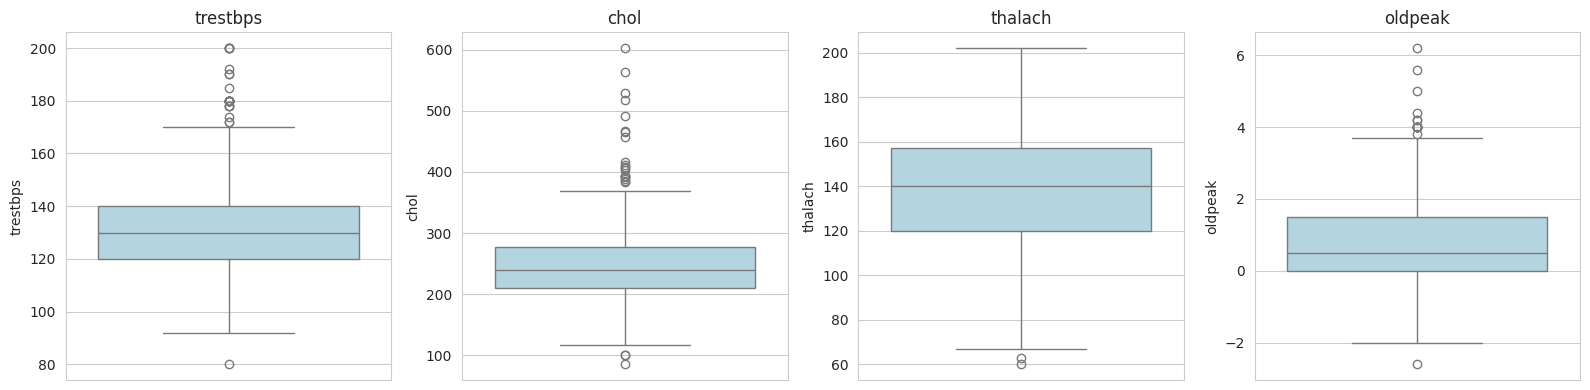

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['trestbps', 'chol', 'thalach', 'oldpeak']):
    sns.boxplot(y=df_clean[col], ax=ax, color='lightblue')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

In [10]:
for col in continuous_cols:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_clean[col] < Q1 - 1.5 * IQR) | (df_clean[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col}: {n_out} outliers")

trestbps: 27 outliers
chol: 23 outliers
thalach: 2 outliers
oldpeak: 16 outliers


### 5.6 Target Variable Encoding

**Task:** Convert `num` (0 = absence, 1-4 = increasing severity) into a binary target: 0 = no heart disease, 1 = heart disease present.

In [11]:
df_clean['target'] = (df_clean['num'] > 0).astype(int)
df_model = df_clean.drop(columns=['num', 'source'])

print(df_clean['target'].value_counts())
print(f"\nClass balance: {df_clean['target'].mean()*100:.1f}% positive (disease present)")

target
1    508
0    410
Name: count, dtype: int64

Class balance: 55.3% positive (disease present)


### 5.7 Train-Test Split, Imputation, Outlier Capping and Scaling

**Task:** Split the data into 80% training and 20% testing first. Then, using the training data only, fill missing numeric values with the median and missing categorical values with the most frequent value, cap outliers with the IQR rule, and standardise all features. Apply the same values to the test data.

In [12]:
feature_cols = [c for c in df_model.columns if c != 'target']
X = df_model[feature_cols]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

median_imputer = SimpleImputer(strategy='median').fit(X_train[continuous_cols])
mode_imputer = SimpleImputer(strategy='most_frequent').fit(X_train[categorical_cols])

train_filled = X_train[continuous_cols].copy()
train_filled[:] = median_imputer.transform(train_filled)
Q1 = train_filled.quantile(0.25)
Q3 = train_filled.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

def preprocess(data):
    data = data.copy()
    data[continuous_cols] = median_imputer.transform(data[continuous_cols])
    data[categorical_cols] = mode_imputer.transform(data[categorical_cols])
    data[continuous_cols] = data[continuous_cols].clip(lower, upper, axis=1)
    return data

scaler = StandardScaler()
X_train = scaler.fit_transform(preprocess(X_train))
X_test = scaler.transform(preprocess(X_test))
X_scaled = scaler.transform(preprocess(X))

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Missing values in training data:", np.isnan(X_train).sum())

Training set size: (734, 11)
Testing set size: (184, 11)
Missing values in training data: 0


## 6. Data Visualization

**Task:** Plot the target class distribution and how sex and chest pain type relate to heart disease.

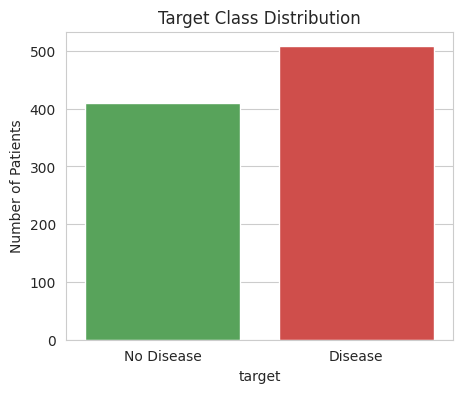

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df_clean, palette=['#4CAF50', '#E53935'])
plt.xticks([0,1], ['No Disease', 'Disease'])
plt.title('Target Class Distribution')
plt.ylabel('Number of Patients')
plt.savefig('target_distribution.png')
plt.show()

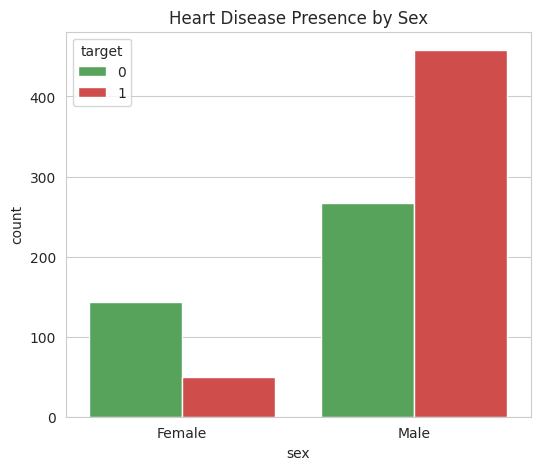

In [14]:
plt.figure(figsize=(6,5))
sns.countplot(x='sex', hue='target', data=df_clean, palette=['#4CAF50', '#E53935'])
plt.xticks([0,1], ['Female', 'Male'])
plt.title('Heart Disease Presence by Sex')
plt.savefig('sex_distribution.png')
plt.show()

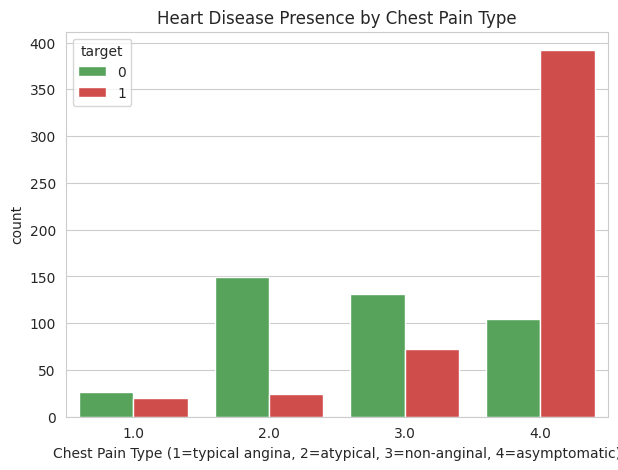

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(x='cp', hue='target', data=df_clean, palette=['#4CAF50', '#E53935'])
plt.title('Heart Disease Presence by Chest Pain Type')
plt.xlabel('Chest Pain Type (1=typical angina, 2=atypical, 3=non-anginal, 4=asymptomatic)')
plt.savefig('cp_distribution.png')
plt.show()

## 7. Feature Correlation

**Task:** Plot the correlation matrix and list the features most correlated with heart disease.

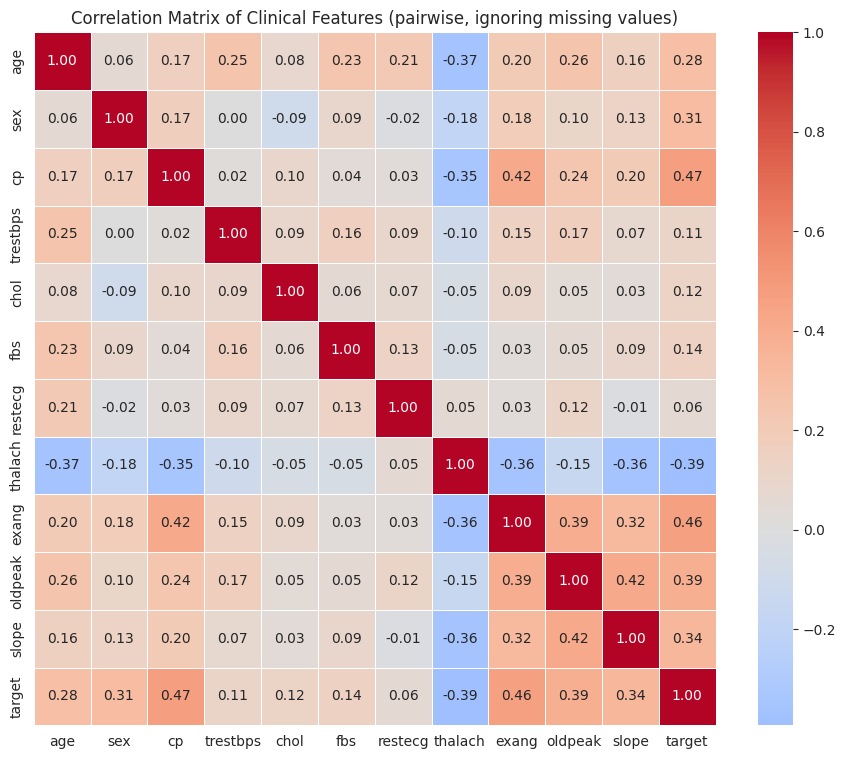

In [16]:
plt.figure(figsize=(11, 9))
corr = df_model.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix of Clinical Features (pairwise, ignoring missing values)')
plt.savefig('correlation_matrix.png')
plt.show()

In [17]:
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print("Features most correlated with heart disease presence:")
target_corr

Features most correlated with heart disease presence:


,target
cp,0.471354
exang,0.462422
thalach,-0.393371
oldpeak,0.386106
slope,0.337086
sex,0.305445
age,0.282039
fbs,0.142725
chol,0.119123
trestbps,0.114705


## 8. Supervised Learning Algorithms

**Task:** Train five classification algorithms on the training set. Evaluate each one on the test set with accuracy, precision, recall, F1-score and a confusion matrix. One helper function evaluates every model so the comparison is fair.

In [18]:
import os
os.makedirs('figures', exist_ok=True)

results = {}
trained_models = {}

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec  = recall_score(y_test, pred, zero_division=0)
    f1   = f1_score(y_test, pred, zero_division=0)

    results[name] = {
        'Accuracy': round(acc, 3), 'Precision': round(prec, 3),
        'Recall (Sensitivity)': round(rec, 3), 'F1-score': round(f1, 3)
    }
    trained_models[name] = model

    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(4,3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease','Disease'], yticklabels=['No Disease','Disease'])
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    file_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'figures/confusion_matrix_{file_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    return model

### 8.1 Logistic Regression

**Task:** Train and evaluate Logistic Regression.

**Principle:** models the log-odds of the positive class as a linear combination of the features, $P(y=1|x) = 1 / (1 + e^{-(w \cdot x + b)})$. The weights are learned by maximizing the likelihood.

--- Logistic Regression ---
Accuracy: 0.793 | Precision: 0.802 | Recall: 0.833 | F1: 0.817


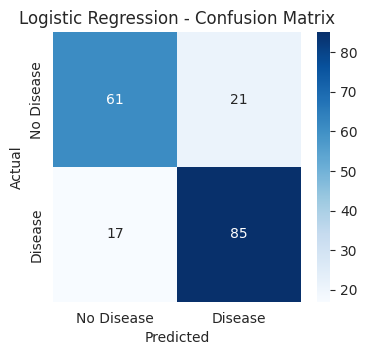

LogisticRegression(max_iter=1000, random_state=42)

In [19]:
evaluate_model('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42))

### 8.2 K-Nearest Neighbors (KNN)

**Task:** Train and evaluate KNN with k = 7.

**Principle:** classifies a point by the majority class among its k nearest neighbors in feature space, using Euclidean distance. It needs scaled features.

--- KNN ---
Accuracy: 0.810 | Precision: 0.802 | Recall: 0.873 | F1: 0.836


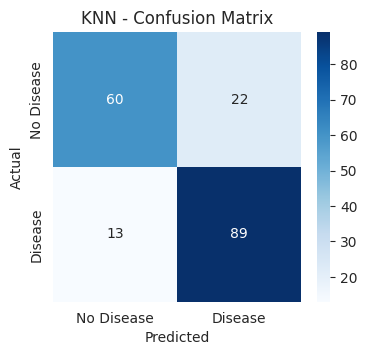

KNeighborsClassifier(n_neighbors=7)

In [20]:
evaluate_model('KNN', KNeighborsClassifier(n_neighbors=7))

### 8.3 Decision Tree

**Task:** Train and evaluate a Decision Tree with maximum depth 5, then plot its top two levels.

**Principle:** recursively splits the data to minimize Gini impurity $G = 1 - \sum_k p_k^2$ at each node, producing interpretable if-else rules.

--- Decision Tree ---
Accuracy: 0.750 | Precision: 0.746 | Recall: 0.833 | F1: 0.787


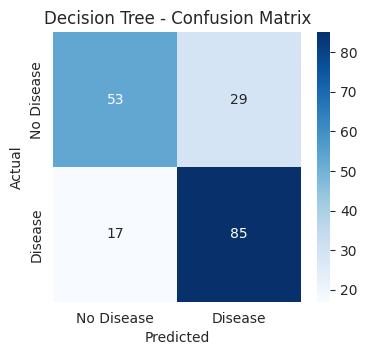

In [21]:
dt_model = evaluate_model('Decision Tree', DecisionTreeClassifier(max_depth=5, random_state=42))

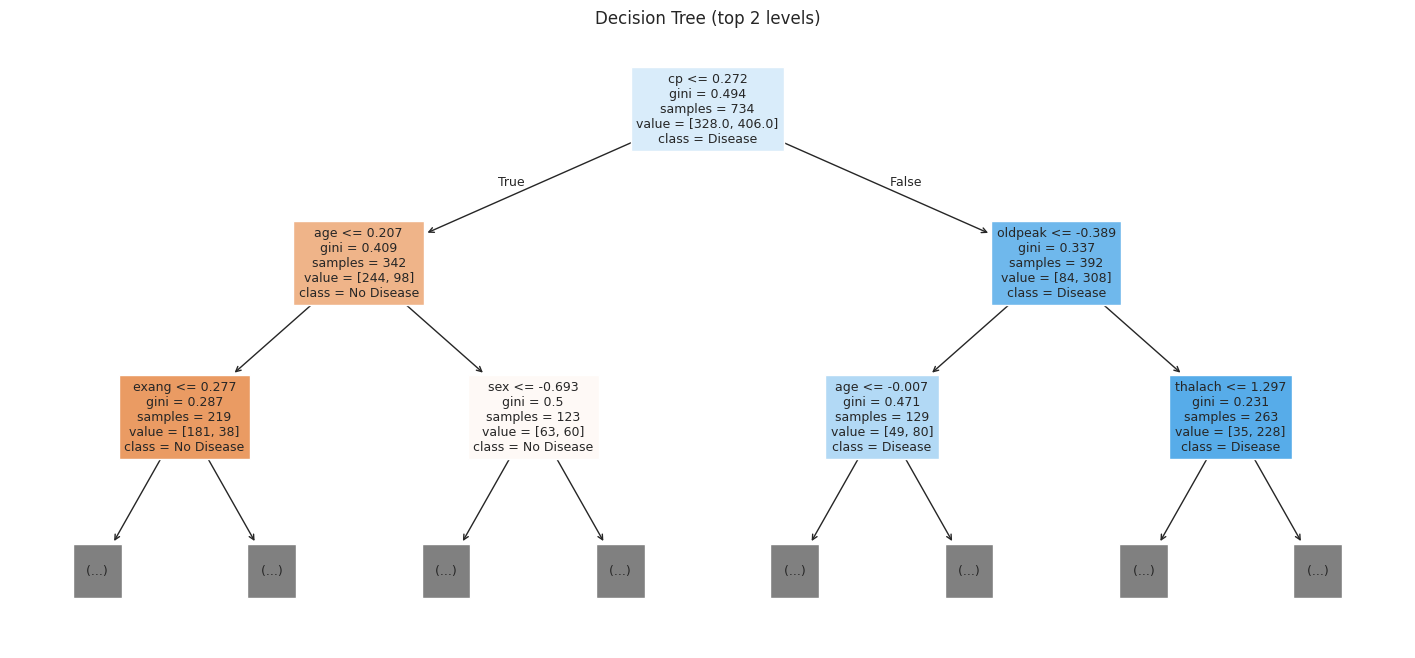

In [22]:
plt.figure(figsize=(18, 8))
plot_tree(dt_model, max_depth=2, feature_names=feature_cols,
          class_names=['No Disease', 'Disease'], filled=True, fontsize=9)
plt.title('Decision Tree (top 2 levels)')
plt.savefig('decision_tree.png')
plt.show()

### 8.4 Random Forest

**Task:** Train and evaluate a Random Forest, then plot its feature importance.

**Principle:** an ensemble of many decision trees, each trained on a bootstrap sample with a random subset of features. The final prediction is the majority vote, which reduces overfitting compared with a single tree.

--- Random Forest ---
Accuracy: 0.810 | Precision: 0.802 | Recall: 0.873 | F1: 0.836


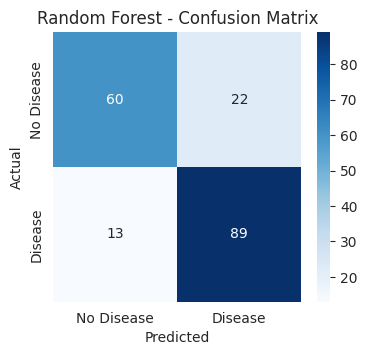

In [23]:
rf_model = evaluate_model('Random Forest',
                          RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42))

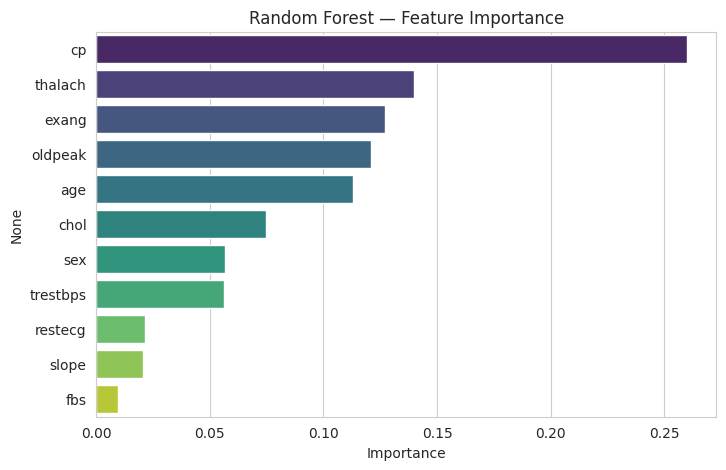

In [24]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.savefig('rf_feature_importance.png')
plt.show()

### 8.5 Support Vector Machine (SVM)

**Task:** Train and evaluate an SVM with the RBF kernel.

**Principle:** finds the hyperplane that maximizes the margin between the classes. The RBF kernel $K(x, x') = e^{-\gamma \lVert x - x' \rVert^2}$ maps the features to a higher-dimensional space to handle non-linear boundaries.

--- SVM (RBF Kernel) ---
Accuracy: 0.815 | Precision: 0.804 | Recall: 0.882 | F1: 0.841


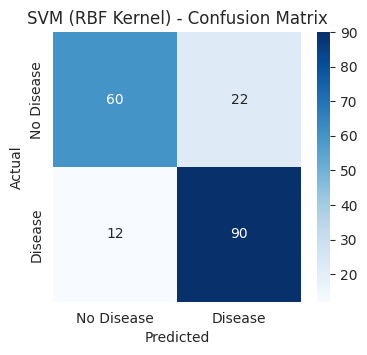

SVC(random_state=42)

In [25]:
evaluate_model('SVM (RBF Kernel)', SVC(kernel='rbf', random_state=42))

## 9. Unsupervised Learning Algorithms

**Task:** Group the patients into 2 clusters without using the diagnosis labels, using K-Means and Hierarchical clustering. The clusters are then compared with the true diagnosis using the silhouette score (cluster separation, near 0 = overlapping) and the Adjusted Rand Index (agreement with the true labels, 0 = random, 1 = perfect).

### 9.1 K-Means Clustering

**Task:** Fit K-Means with 2 clusters, evaluate it and plot the clusters in 2D using PCA.
**Principle:** minimizes the within-cluster sum of squares $\sum_i \lVert x_i - \mu_{c(i)} \rVert^2$ by alternately assigning points to the nearest centroid and recomputing the centroids.

In [26]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

km_sil = silhouette_score(X_scaled, km_labels)
km_ari = adjusted_rand_score(y, km_labels)
print(f"K-Means Silhouette Score: {km_sil:.3f}")
print(f"K-Means Adjusted Rand Index (agreement with true labels): {km_ari:.3f}")

ct = pd.crosstab(km_labels, y, rownames=['Cluster'], colnames=['Actual Target'])
print("\nCluster vs Actual Target crosstab:")
print(ct)

K-Means Silhouette Score: 0.153
K-Means Adjusted Rand Index (agreement with true labels): 0.303

Cluster vs Actual Target crosstab:
Actual Target    0    1
Cluster                
0               73  375
1              337  133


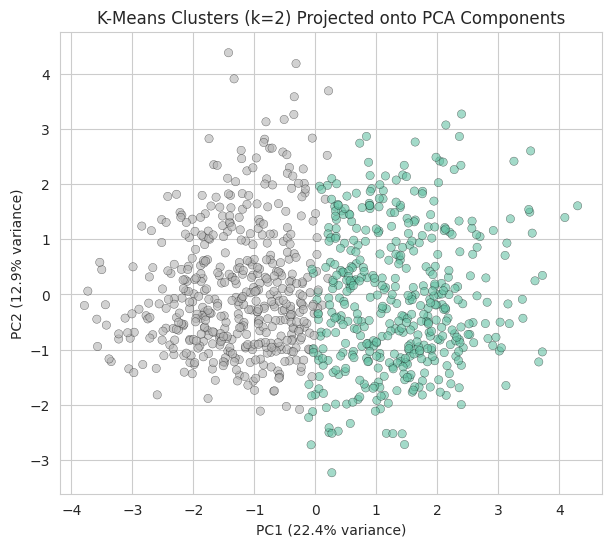

In [27]:
pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=km_labels, cmap='Set2', alpha=0.6, edgecolor='k', linewidth=0.3)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Means Clusters (k=2) Projected onto PCA Components')
plt.savefig('kmeans_clusters.png')
plt.show()

## 10. Comparative Analysis and Model Selection

### 10.1 Comparison of Supervised Algorithms

**Task:** Compare the five models on every metric. The table also shows the training accuracy: a large gap between training and test accuracy means the model is overfitting. The best model is the one with the highest test accuracy, which is then checked against the requirement of more than 80%.

In [28]:
classification_comparison = pd.DataFrame(results).T
classification_comparison['Train Accuracy'] = pd.Series({n: round(m.score(X_train, y_train), 3) for n, m in trained_models.items()})
classification_comparison['Train-Test Gap'] = (classification_comparison['Train Accuracy'] - classification_comparison['Accuracy']).round(3)
classification_comparison = classification_comparison.sort_values('Accuracy', ascending=False)
classification_comparison

,Accuracy,Precision,Recall (Sensitivity),F1-score,Train Accuracy,Train-Test Gap
SVM (RBF Kernel),0.815,0.804,0.882,0.841,0.856,0.041
Random Forest,0.810,0.802,0.873,0.836,0.895,0.085
KNN,0.810,0.802,0.873,0.836,0.834,0.024
Logistic Regression,0.793,0.802,0.833,0.817,0.805,0.012
Decision Tree,0.750,0.746,0.833,0.787,0.854,0.104


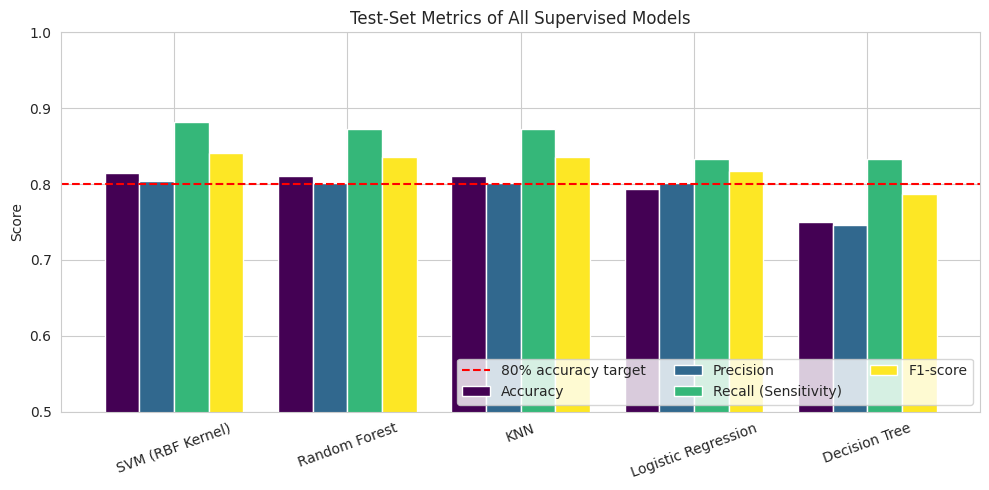

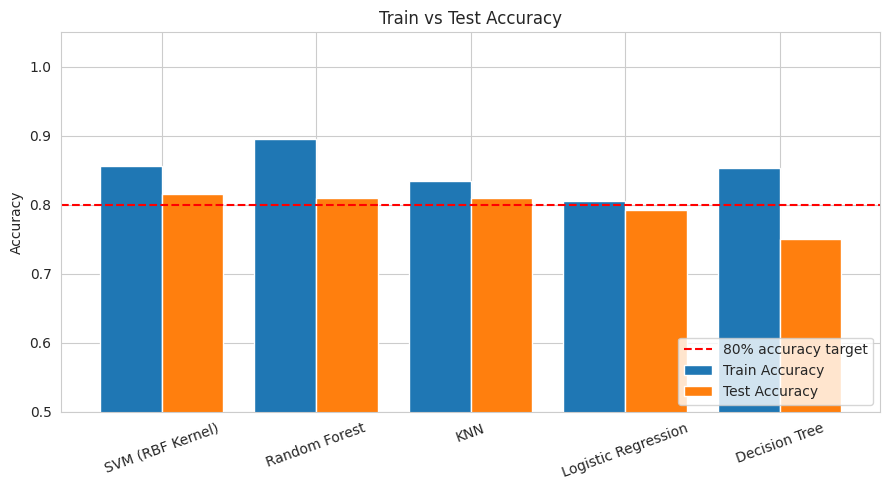

In [29]:
test_metrics = ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1-score']
classification_comparison[test_metrics].plot(kind='bar', figsize=(10, 5), width=0.8, colormap='viridis')
plt.axhline(y=0.80, color='red', linestyle='--', label='80% accuracy target')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.title('Test-Set Metrics of All Supervised Models')
plt.xticks(rotation=20)
plt.legend(loc='lower right', ncol=3)
plt.tight_layout()
plt.savefig('supervised_metrics.png')
plt.show()

classification_comparison[['Train Accuracy', 'Accuracy']].plot(kind='bar', figsize=(9, 5), width=0.8)
plt.axhline(y=0.80, color='red', linestyle='--', label='80% accuracy target')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.05)
plt.title('Train vs Test Accuracy')
plt.xticks(rotation=20)
plt.legend(['80% accuracy target', 'Train Accuracy', 'Test Accuracy'], loc='lower right')
plt.tight_layout()
plt.savefig('train_test_accuracy.png')
plt.show()

In [30]:
for metric in test_metrics:
    best_for_metric = classification_comparison[metric].idxmax()
    print(f"Best {metric:22s}: {best_for_metric} ({classification_comparison.loc[best_for_metric, metric]})")
print("Smallest train-test gap (least overfitting):", classification_comparison['Train-Test Gap'].idxmin())

best_model_name = classification_comparison['Accuracy'].idxmax()
best_acc = classification_comparison.loc[best_model_name, 'Accuracy']
print()
print(f"Best-performing model: {best_model_name} with Accuracy = {best_acc}")
print(f"Requirement (accuracy > 0.80) met: {best_acc > 0.80}")
print("Models above 0.80 accuracy:", list(classification_comparison.index[classification_comparison['Accuracy'] > 0.80]))

Best Accuracy              : SVM (RBF Kernel) (0.815)
Best Precision             : SVM (RBF Kernel) (0.804)
Best Recall (Sensitivity)  : SVM (RBF Kernel) (0.882)
Best F1-score              : SVM (RBF Kernel) (0.841)
Smallest train-test gap (least overfitting): Logistic Regression

Best-performing model: SVM (RBF Kernel) with Accuracy = 0.815
Requirement (accuracy > 0.80) met: True
Models above 0.80 accuracy: ['SVM (RBF Kernel)', 'Random Forest', 'KNN']


### 10.2 Evaluation of the Unsupervised Algorithm

**Task:** Compare K-Means with 2 to 5 clusters using the silhouette score and the Adjusted Rand Index, to check whether 2 clusters (disease / no disease) is the natural grouping.

In [31]:
clustering_results = {}
for k in range(2, 6):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    clustering_results[f'K-Means (k={k})'] = {'Silhouette Score': round(silhouette_score(X_scaled, labels), 3),
                                              'Adjusted Rand Index': round(adjusted_rand_score(y, labels), 3)}
clustering_comparison = pd.DataFrame(clustering_results).T
clustering_comparison

,Silhouette Score,Adjusted Rand Index
K-Means (k=2),0.153,0.303
K-Means (k=3),0.167,0.219
K-Means (k=4),0.159,0.141
K-Means (k=5),0.123,0.144


In [32]:
best_cluster_algo = clustering_comparison['Adjusted Rand Index'].astype(float).idxmax()
print(f"Observation: '{best_cluster_algo}' aligns most closely with the true disease "
      f"labels (ARI = {clustering_comparison.loc[best_cluster_algo, 'Adjusted Rand Index']}), "
      f"though — as expected — unsupervised clustering alone is less accurate than "
      f"supervised classification, since it has no access to the target labels during training.")

Observation: 'K-Means (k=2)' aligns most closely with the true disease labels (ARI = 0.303), though — as expected — unsupervised clustering alone is less accurate than supervised classification, since it has no access to the target labels during training.


## 11. Conclusion and Real-World Applications

### 11.1 Final Results

**Task:** Print the final supervised and unsupervised results.

In [33]:
print("Best supervised model:", best_model_name)
print("Test accuracy:", best_acc)
print("Requirement (accuracy > 80%) met:", best_acc > 0.80)
print()
print("K-Means (k=2) -> Silhouette:", round(km_sil, 3), "| ARI:", round(km_ari, 3))

Best supervised model: SVM (RBF Kernel)
Test accuracy: 0.815
Requirement (accuracy > 80%) met: True

K-Means (k=2) -> Silhouette: 0.153 | ARI: 0.303


### 11.2 Key Findings
- The dataset (920 patient records from 4 hospitals) required substantial preprocessing: invalid zero cholesterol/blood-pressure values were treated as missing, two columns with more than half their values missing (`ca`, `thal`) were dropped, duplicates were removed, and outliers were capped.
- All learned preprocessing (imputation, outlier limits, scaling) was fitted on the training set only, so the results are free of data leakage.
- Five supervised algorithms were compared using accuracy, precision, recall, F1-score, confusion matrices and a train-test accuracy gap. The best model and the check against the 80% requirement are printed in Section 11.1.
- The correlation table (Section 7) and Random Forest feature importance (Section 8.4) show which clinical features matter most.
- Unsupervised clustering (K-Means) found only weakly separated groups (low silhouette scores) and agrees only partly with the true diagnosis, so it is useful for exploration but less accurate than supervised classification, which uses the labels.

### 11.3 Real-World Applications
- **Clinical decision support:** flagging high-risk patients for further cardiac testing (e.g., angiography) using only routine, low-cost clinical measurements.
- **Preventive healthcare screening:** integrating the model into hospital intake systems or wearable-health apps for early risk alerts.
- **Resource prioritization:** helping hospitals with limited specialist cardiology resources triage patients more efficiently.
- In screening, recall (not missing a sick patient) matters most, so the decision threshold would be lowered in practice.

### 11.4 Limitations
- The dataset is small (920 records) and was collected in the late 1980s; performance on modern, larger populations may differ. With only 184 test patients, accuracy figures have a margin of error of several percentage points.
- `ca` and `thal` are strong predictors where recorded, but were dropped because they are mostly missing. Cholesterol is missing for about one fifth of patients and was imputed, which can introduce bias.
- The four hospitals have different populations and measurement practices, so performance may not transfer to a new hospital.
- The model predicts disease *presence*, not severity or prognosis, and supports but does not replace a clinician.

### 11.5 Future Scope
- Collect a larger, more recent and more complete dataset, including the vessel and thallium test results.
- Experiment with advanced ensemble methods (XGBoost, Gradient Boosting) and deep learning (ANNs).
- Deploy the best model as a simple web app for clinical use, with proper validation and regulatory review.

## 12. References
1. UCI Machine Learning Repository — Heart Disease Dataset: https://archive.ics.uci.edu/dataset/45/heart+disease
2. Detrano, R., et al. (1989). *International application of a new probability algorithm for the diagnosis of coronary artery disease.* American Journal of Cardiology, 64, 304-310.
3. Scikit-learn documentation: https://scikit-learn.org/stable/
4. World Health Organization — Cardiovascular diseases (CVDs) fact sheet.